In [ ]:
library(numbat)
library(dplyr)
library(Seurat)
library(data.table)
library(ggplot2)
library(dplyr)
library(glue)
library(ggtree)
library(stringr)
library(tidygraph)
library(patchwork)
library(gridExtra)
library(grid)
library(future)
plan("multicore", workers = 12)
options(future.globals.maxSize = 10000 * 1024^10,
        future.rng.onMisuse = 'ignore')
sessionInfo()

Loading required package: Matrix


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


ggtree v3.6.2 For help: https://yulab-smu.top/treedata-book/

If you use the ggtree package suite in published research, please cite
the appropriate paper(s):

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan, Tommy Tsan-

R version 4.2.3 (2023-03-15)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 8.7 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_python/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.32.0           gridExtra_2.3           patchwork_1.1.2        
 [4] tidygraph_1.2.3         stringr_1.5.0           ggtree_3.6.2           
 [7] glue_1.6.2              ggplot2_3.4.1           data.table_1.14.8      
[10] Seurat_4.9.9.9040       SeuratOb

In [ ]:
dmg <- readRDS('/projects/0/einf2548/cruiz/dmg/data/merged_dmg_atlas_qc_filtered.rds')
dmg

An object of class Seurat 
38576 features across 409561 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [ ]:
dmg <- subset(dmg, Batch_for_correction == '10Xv3_cell_rna')
dmg

An object of class Seurat 
38576 features across 57305 samples within 6 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 5 other assays present: RAW, prediction.score.annotation_level_1, prediction.score.annotation_level_2, prediction.score.annotation_level_3, prediction.score.annotation_level_4
 4 dimensional reductions calculated: pca, umap, ref.pca, ref.umap

In [ ]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,5209292,278.3,9117428,487.0,9117428,487
Vcells,853322237,6510.4,7275309818,55506.3,7548305138,57589


In [ ]:
samples <- names(table(dmg$SampleID))
samples <- gsub('_RNA_only', '', samples)
samples 

[1] "P-6117_S-8370" "P-6240_S-8628" "P-6328_S-8672" "P-6337_S-8821"
[5] "P-6519_S-9084"

In [ ]:
options(warn = 0)

Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name                  grob
1 1 (1-1,1-1) arrange gTree[GRID.gTree.179]
2 2 (2-2,1-1) arrange gTree[GRID.gTree.181]


Warning message:
“ggrepel: 3 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


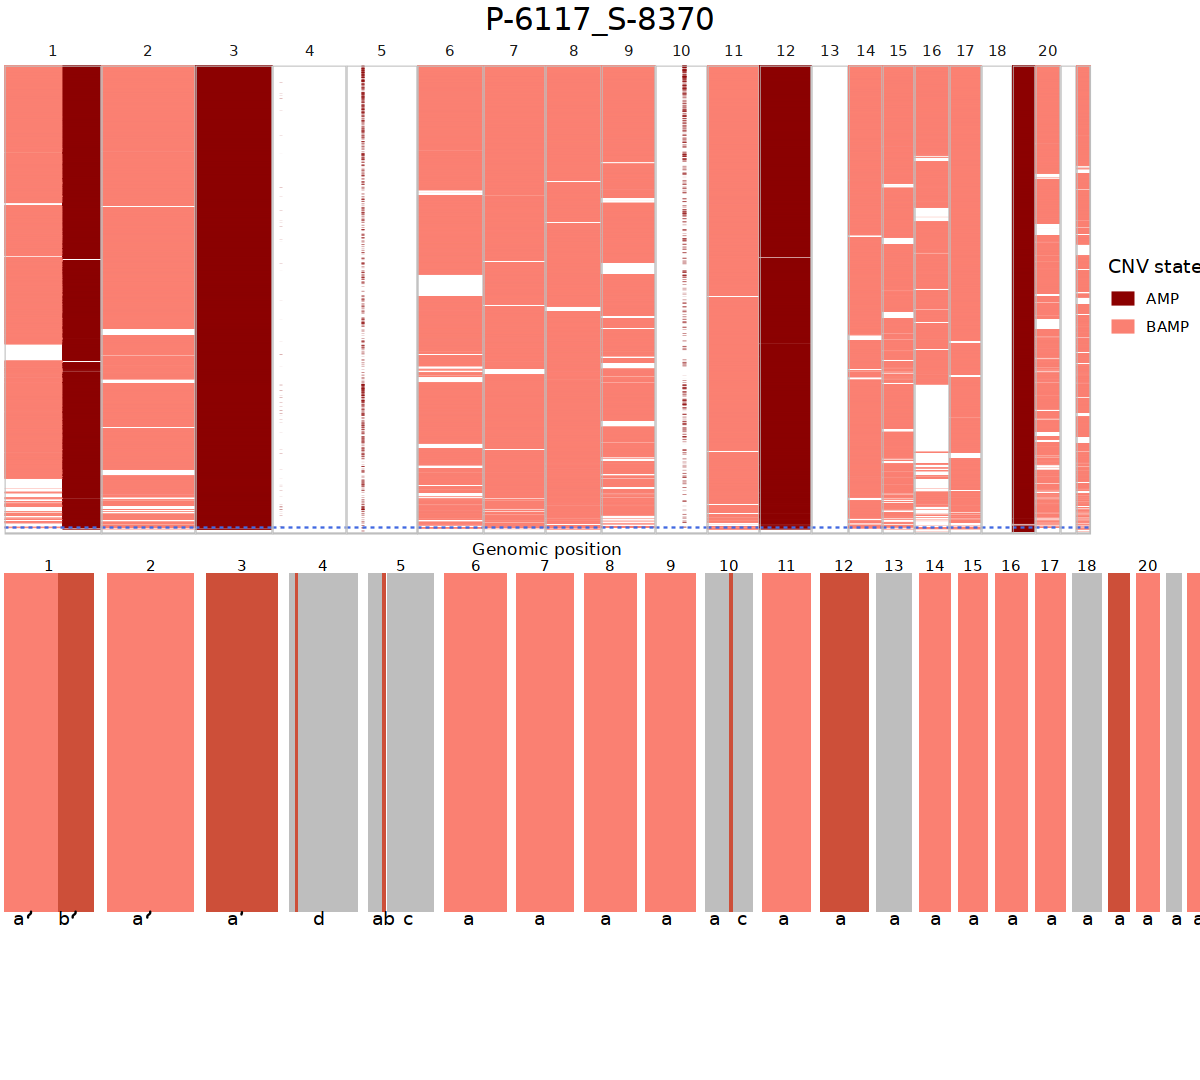

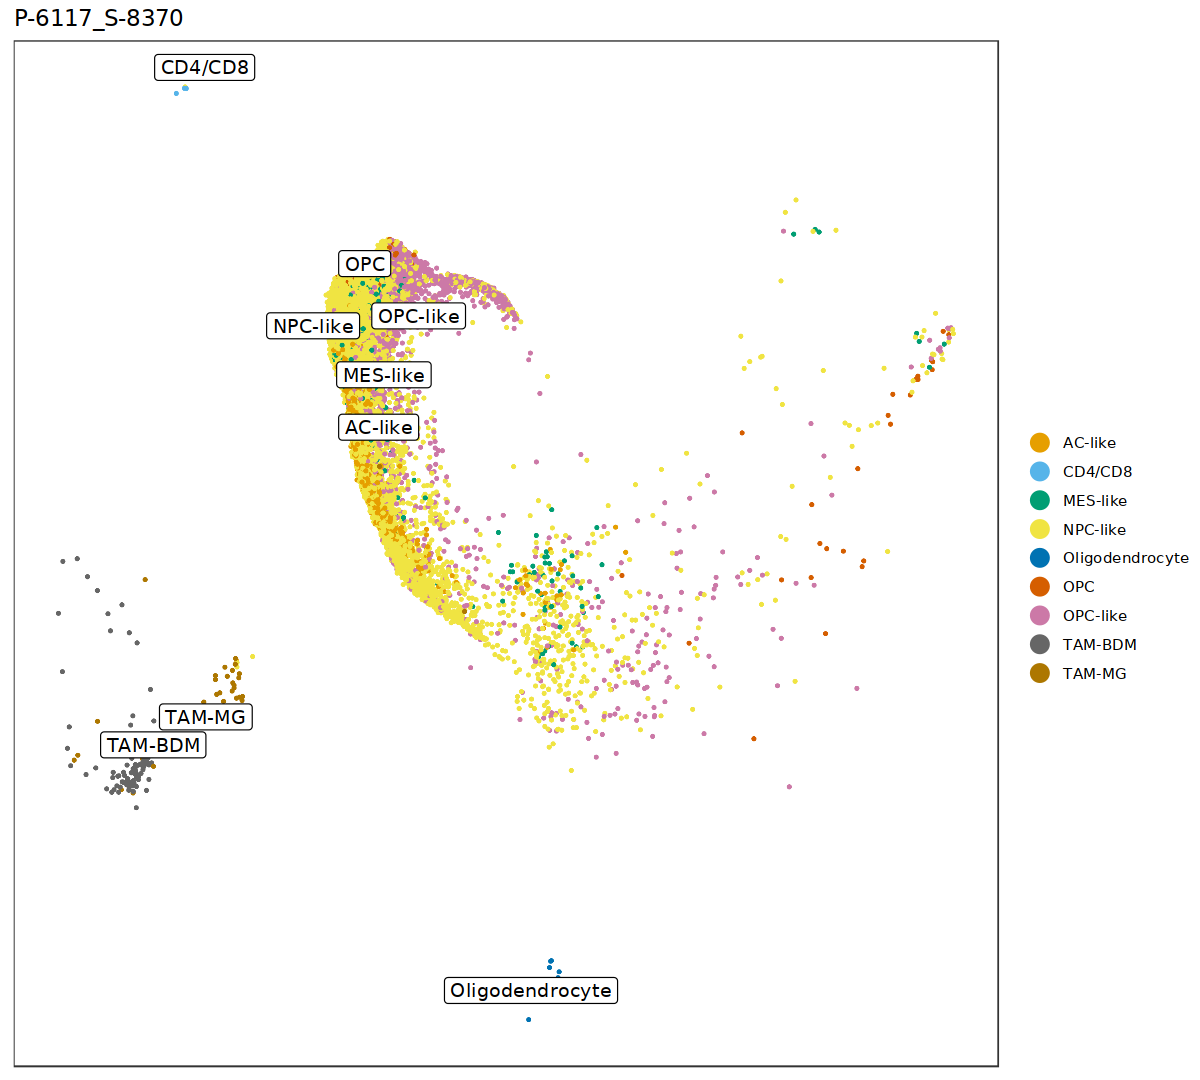

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name                   grob
1 1 (1-1,1-1) arrange gTree[GRID.gTree.1516]
2 2 (2-2,1-1) arrange gTree[GRID.gTree.1518]


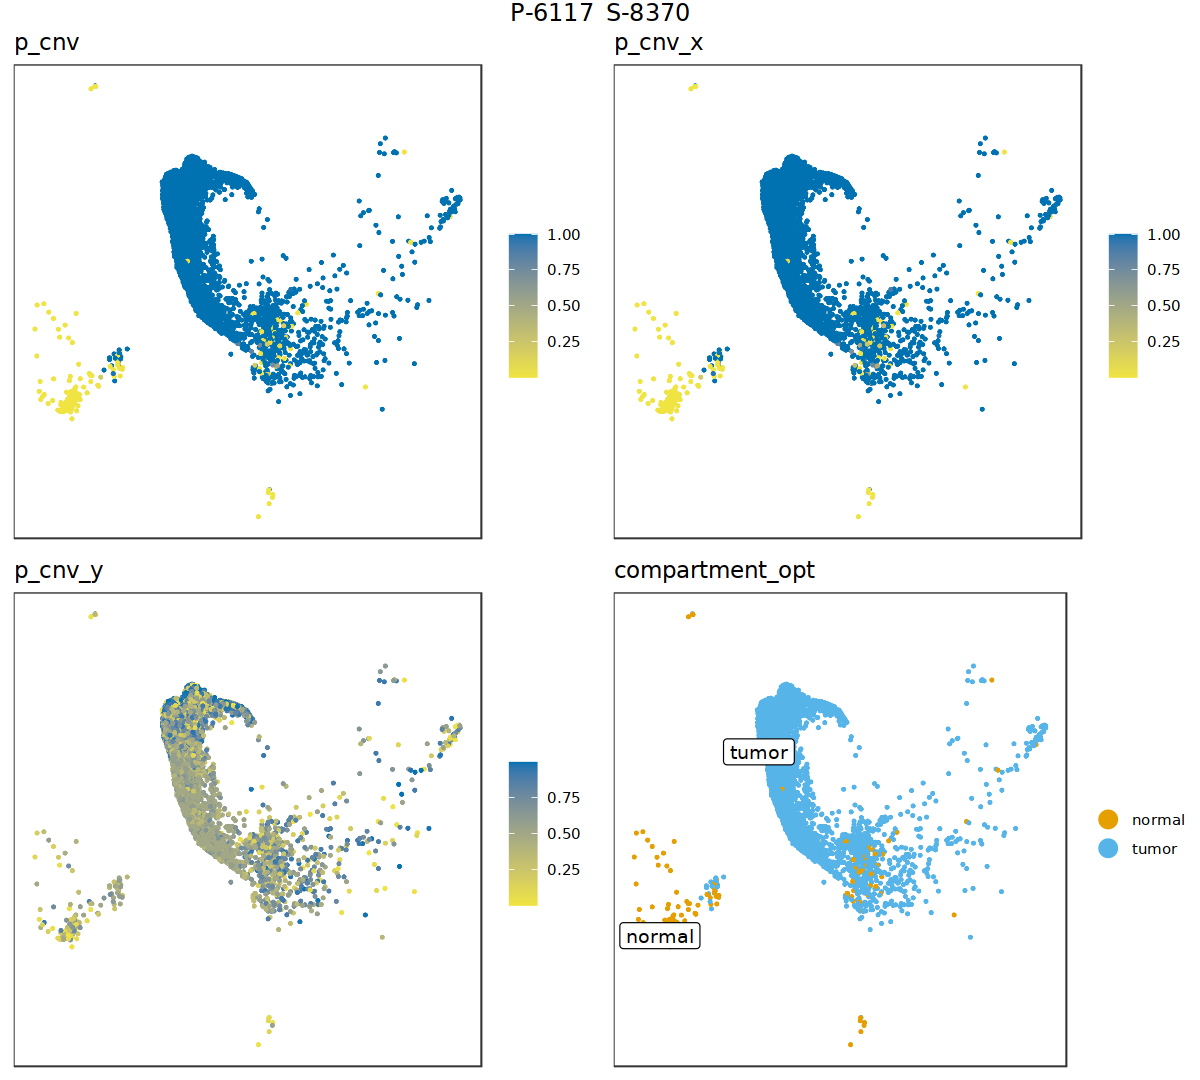

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name                   grob
1 1 (1-1,1-1) arrange gTree[GRID.gTree.1671]
2 2 (2-2,1-1) arrange gTree[GRID.gTree.1673]


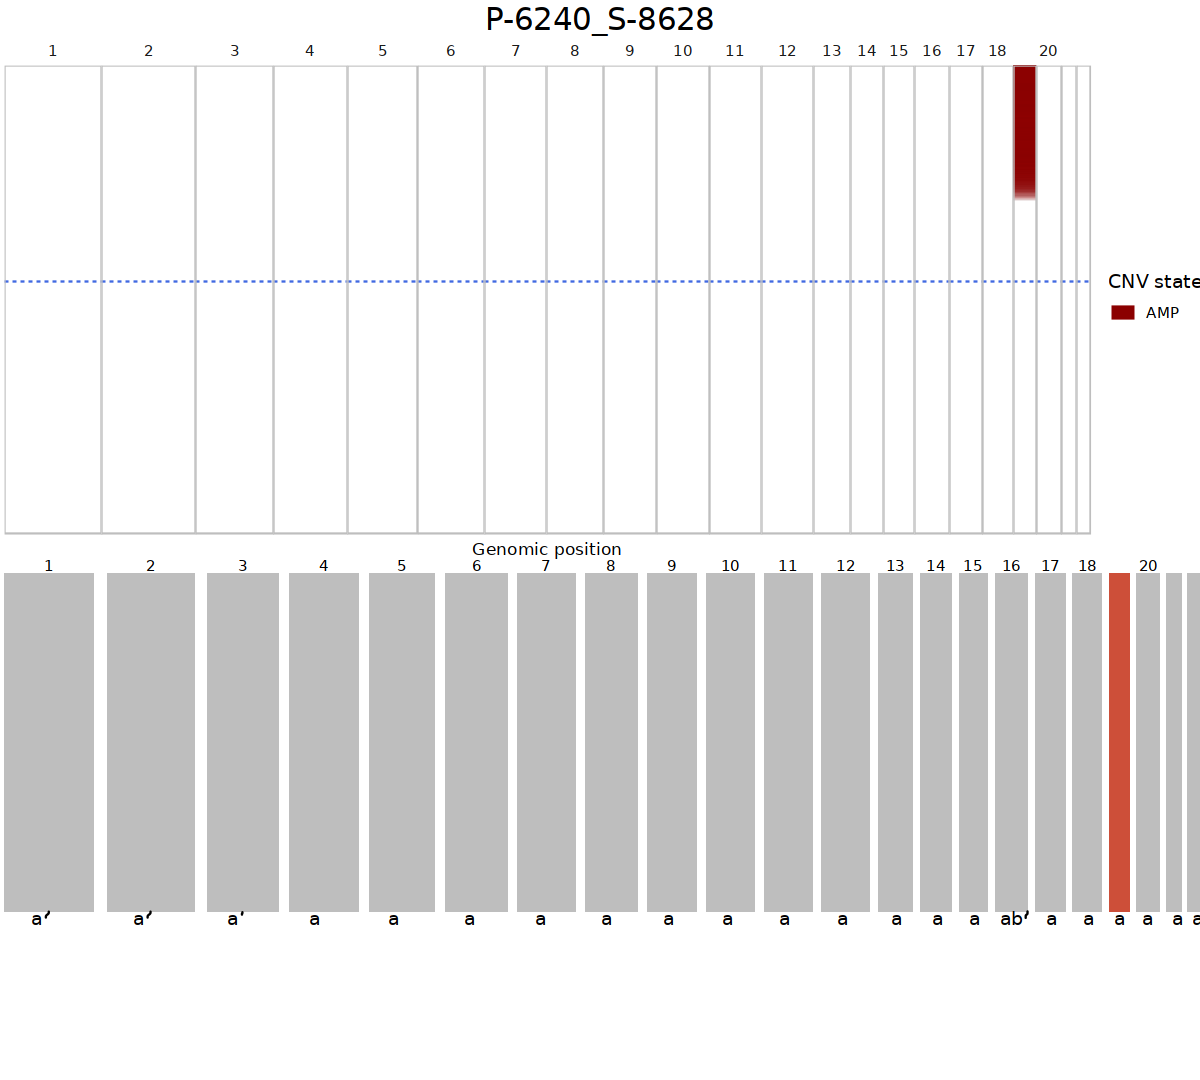

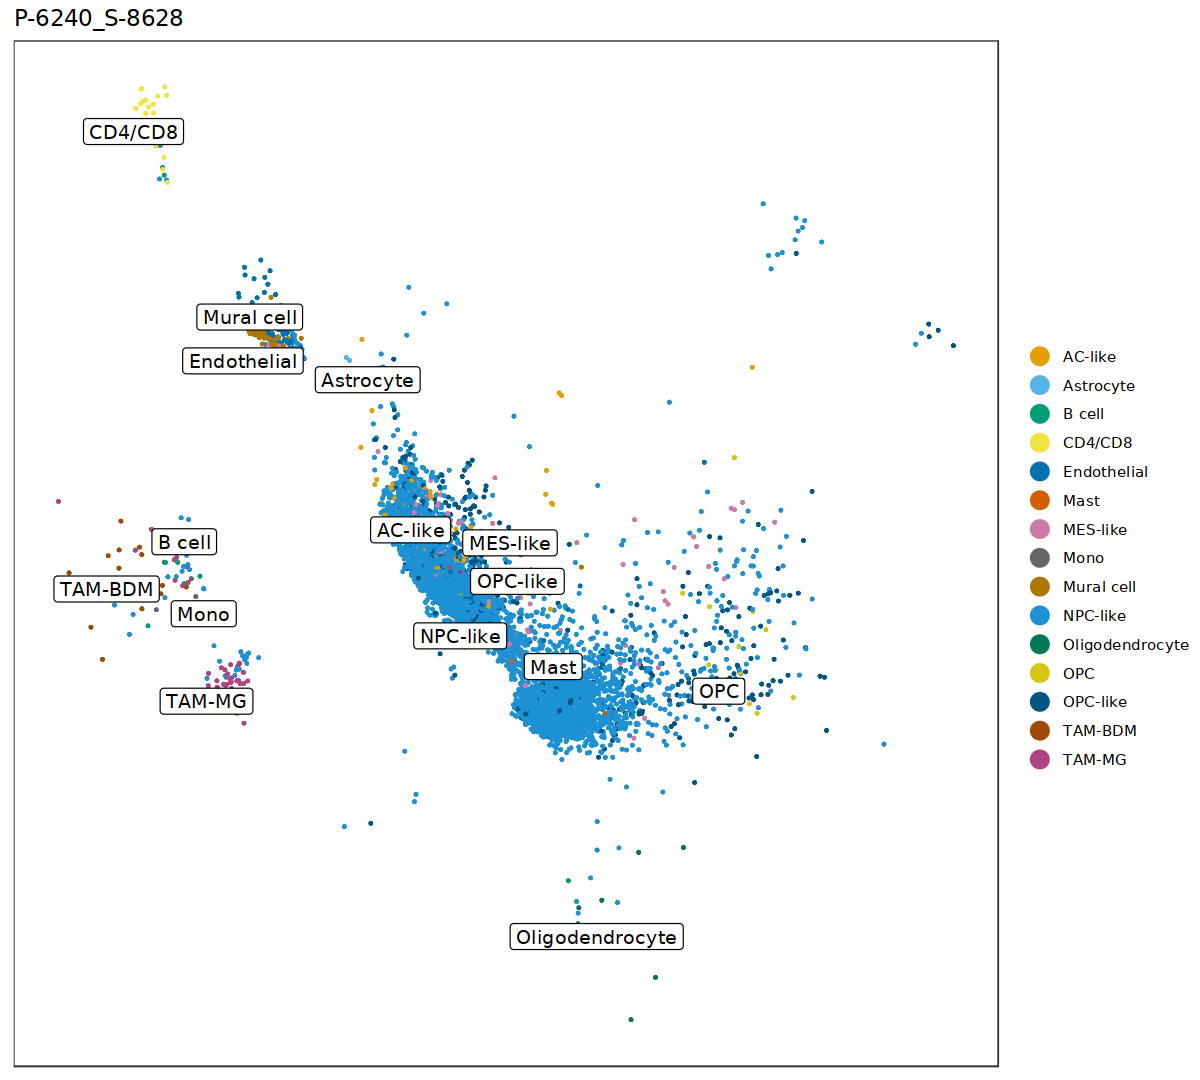

In [ ]:
options(repr.plot.height = 9, repr.plot.width = 10)
for(i in seq_along(samples)){

    nb = Numbat$new(out_dir = paste0('sc/', samples[i]))
    
    p0 <- nb$plot_phylo_heatmap(
          clone_bar = TRUE, 
          p_min = 0.9
        )
    
    p0.1 <- nb$plot_consensus()
  
    print(grid.arrange(
                grobTree(textGrob(samples[i], gp = gpar(fontsize = 18, fontface = "bold"))),
                grobTree(arrangeGrob(p0, p0.1)), heights = unit(c(1.5, 9), c("lines", "null"))
    ))
    
    dmg_subset <- subset(dmg, SampleID == paste0(samples[i], '_RNA_only'))
    
    print(dittoSeq::dittoDimPlot(dmg_subset, 
                   reduction.use = "umap", var = "predicted.annotation_level_3", 
                   do.label = T, labels.size = 4, main = samples[i],
                   do.raster = TRUE) + NoAxes()) 

    meta <- nb$clone_post %>% 
            select(cell, p_cnv, p_cnv_x, p_cnv_y, compartment_opt) %>%
            tibble::column_to_rownames('cell')

    dmg_subset <- AddMetaData(dmg_subset, meta)

        p1 <- dittoSeq::dittoDimPlot(dmg_subset, 
                 reduction.use = "umap", var = "p_cnv", 
                 do.raster = TRUE) + NoAxes()
          
        p2 <- dittoSeq::dittoDimPlot(dmg_subset, 
                       reduction.use = "umap", var = "p_cnv_x", 
                       do.raster = TRUE) + NoAxes()
          
        p3 <- dittoSeq::dittoDimPlot(dmg_subset, 
                       reduction.use = "umap", var = "p_cnv_y", 
                       do.raster = TRUE) + NoAxes()
          
        p4 <- dittoSeq::dittoDimPlot(dmg_subset, 
                       reduction.use = "umap", var = "compartment_opt", 
                       do.label = T, labels.size = 4, 
                       do.raster = TRUE) + NoAxes()
        
        # arrange the plots in a 2x2 grid
        print(grid.arrange(
                grobTree(textGrob(samples[i], gp = gpar(fontsize = 14, fontface = "bold"))),
                grobTree(arrangeGrob(p1, p2, p3, p4, ncol=2)), heights = unit(c(1, 9), c("lines", "null"))
        ))
    
    # Sys.sleep(20)
}

### Extract predictions

In [ ]:
meta_cnv <- list()

for(i in seq_along(samples)){
    
    if (file.exists(paste0('sc/', samples[i],'/bulk_clones_final.tsv.gz')) == TRUE) {
    
    nb = Numbat$new(out_dir = paste0('sc/',samples[i]))

    meta <- nb$clone_post %>% 
            select(cell, p_cnv, p_cnv_x, p_cnv_y, compartment_opt)

    meta_cnv[[i]] <- meta
    } else {next}
}

In [ ]:
length(meta_cnv)

[1] 5

In [ ]:
iCNV <- rbindlist(meta_cnv) %>% tibble::column_to_rownames('cell')
iCNV

,p_cnv,p_cnv_x,p_cnv_y,compartment_opt
,<dbl>,<dbl>,<dbl>,<chr>
rna_P-6117_S-8370_AAACCTGAGATCTGCT-1,1.000000e+00,1.000000e+00,0.764149241,tumor
rna_P-6117_S-8370_AAACCTGAGATGCCTT-1,1.000000e+00,1.000000e+00,0.860041493,tumor
rna_P-6117_S-8370_AAACCTGAGCGCCTCA-1,9.999204e-01,9.999760e-01,0.231523000,tumor
rna_P-6117_S-8370_AAACCTGAGGGCTCTC-1,1.000000e+00,1.000000e+00,0.007913233,tumor
rna_P-6117_S-8370_AAACCTGCAAGTCTAC-1,1.000000e+00,1.000000e+00,0.599306553,tumor
rna_P-6117_S-8370_AAACCTGCAATCAGAA-1,1.000000e+00,1.000000e+00,0.974320985,tumor
rna_P-6117_S-8370_AAACCTGCACACATGT-1,1.000000e+00,1.000000e+00,0.858456790,tumor
rna_P-6117_S-8370_AAACCTGCACAGACTT-1,1.000000e+00,1.000000e+00,0.959576411,tumor
rna_P-6117_S-8370_AAACCTGCACATGGGA-1,1.000000e+00,1.000000e+00,0.769368213,tumor


### Merged

In [ ]:
dmg <-  AddMetaData(dmg, iCNV)

In [ ]:
saveRDS(iCNV, 'numbat_sc_Jessa2022.rds')